# Witness My Entanglement — Full Pipeline Showcase

**Goal**: certify Genuine Multipartite Entanglement on as many qubits as possible on IQM Emerald, in a single end-to-end run.

## Approach in one diagram

```
┌──────────────────────────────────────────────┐
│ 1. Pull live calibration                     │  per-qubit T1/T2/RO/1Q,
│    (no hardware time)                        │  per-edge CZ fidelity
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 2. Threshold filter for stability             │  exclude qubits with
│    (no hardware time)                         │  marginal calibration
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 3. Comprehensive edge cost                    │  CZ + T1 + T2 + 1Q
│    w(u,v) = (1−F_CZ) + decoherence + 1Q       │  (RO excluded — QREM
│                                                │   handles it)
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 4. Multi-start Prim's + local search          │  best n-qubit
│                                                │  spanning tree
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 5. A-priori predict ⟨g_i⟩ and W               │  decide before
│    if predW > n−1: certification is feasible  │  burning shots
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 6. Hardware: 2 circuits per tree              │  IQM Emerald,
│    setting A (black→X), setting B (white→X)   │  1500 shots/circuit
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 7. Compute W and apply parity-QREM            │  per-qubit RO
│    c_i = 1/(P(0|0) + P(1|1) − 1)              │  correction factors
└──────────────────────────────────────────────┘
                       ↓
┌──────────────────────────────────────────────┐
│ 8. Verdict: W > n−1 ⟹ GME at significance σ   │
└──────────────────────────────────────────────┘
```

## Theory

For any connected 2-colorable graph state |G⟩ with stabilizers $g_i = X_i \otimes \bigotimes_{j \in N(i)} Z_j$:

$$W = \sum_i \langle g_i \rangle \;\;\;\;\;\; W \le n-1 \;\Longleftrightarrow\; \text{biseparable}$$

Therefore $W > n-1 \Rightarrow$ **Genuine Multipartite Entanglement** (Tóth & Gühne 2005).

**Why a spanning tree**: minimum n−1 edges → minimum CZ gates → minimum prep error. The bound n−1 is invariant in graph density, so denser graphs only add noise without strengthening the certificate.

In [1]:
import sys, time
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import (
    get_backend, is_simulator,
    get_qubit_metrics, filter_qubits_by_metrics,
    select_best_tree, predict_stabilizer_fidelities,
)
from src.circuits.graph_state import build_graph_state, neighbours_from_edges
from src.witnesses.gme_graph import (
    build_gme_circuits_graph, compute_gme_witness_graph, gme_significance_graph,
)
from src.mitigation.parity_qrem import correction_factors_from_metrics
from src.visualization import plot_device_topology, _device_layout

TARGET_NS = [8, 12, 16, 20]
SHOTS = 1500

backend = get_backend(device='emerald')
print(f'Backend: {backend} (hardware: {not is_simulator(backend)})')
print(f'Sweep: n = {TARGET_NS}, shots/circuit = {SHOTS}')

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x00000186551E5F40> (hardware: True)
Sweep: n = [8, 12, 16, 20], shots/circuit = 1500


## Step 1 — Pull live calibration data

All metrics come from a single REST call to the IQM Resonance API (`get_quality_metric_set`). No hardware time used.

Qubits with metrics: 54
CZ pairs reported : 81


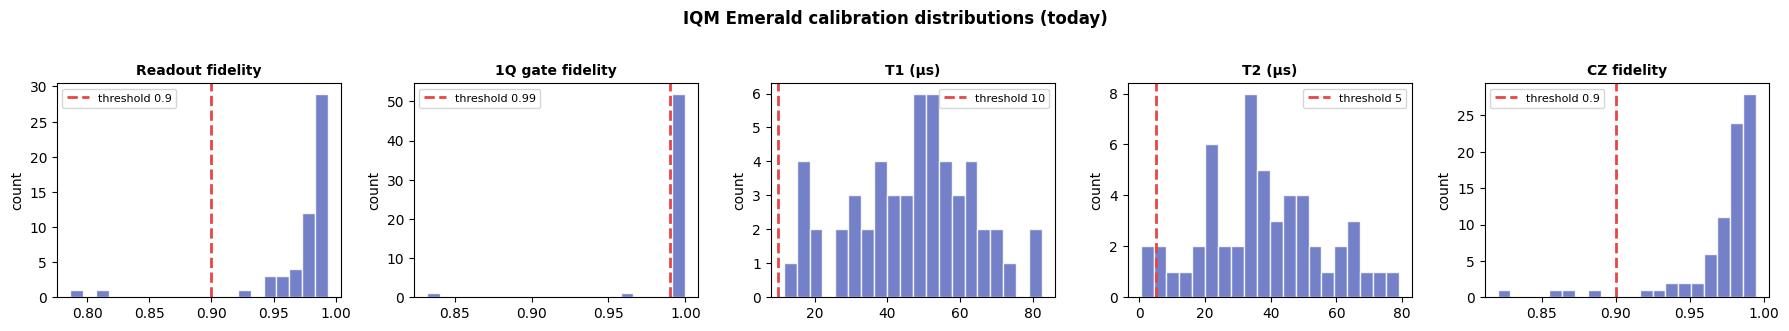

In [2]:
qm, cz = get_qubit_metrics(backend)
print(f'Qubits with metrics: {len(qm)}')
print(f'CZ pairs reported : {len(cz)}')

# Distributions
ro = [m.get('readout_fidelity', 0) for m in qm.values()]
f1 = [m.get('one_q_fidelity', 0) for m in qm.values()]
t1 = [m.get('t1', 0) * 1e6 for m in qm.values() if m.get('t1')]
t2 = [m.get('t2', 0) * 1e6 for m in qm.values() if m.get('t2')]
cz_vals = list(cz.values())

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, vals, title, threshold in zip(
    axes,
    [ro, f1, t1, t2, cz_vals],
    ['Readout fidelity', '1Q gate fidelity', 'T1 (µs)', 'T2 (µs)', 'CZ fidelity'],
    [0.90, 0.99, 10, 5, 0.90],
):
    ax.hist(vals, bins=20, color='#5c6bc0', alpha=0.85, edgecolor='white')
    ax.axvline(threshold, color='#e84545', linestyle='--', linewidth=2, label=f'threshold {threshold}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.suptitle('IQM Emerald calibration distributions (today)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 2 — Threshold filter for stability

Empirically, qubits with marginal calibration drift more than headline metrics suggest. The threshold filter excludes them before optimization. Default thresholds:

- Readout fidelity ≥ 0.90
- 1Q gate fidelity ≥ 0.99
- T1 ≥ 10 µs
- T2 ≥ 5 µs
- Best CZ partner fidelity ≥ 0.90

In [3]:
good = filter_qubits_by_metrics(qm, cz)
excluded = sorted(set(range(backend.num_qubits)) - good)
print(f'Qubits passing thresholds: {len(good)}/{backend.num_qubits}')
print(f'Excluded qubits (with reasons):')
for idx in excluded:
    m = qm.get(idx, {})
    fails = []
    if m.get('readout_fidelity', 0) < 0.90: fails.append(f"RO={m.get('readout_fidelity', 0):.3f}")
    if m.get('one_q_fidelity', 0) < 0.99: fails.append(f"1Q={m.get('one_q_fidelity', 0):.4f}")
    if (m.get('t1') or 0) < 10e-6: fails.append(f"T1={m.get('t1', 0)*1e6:.0f}µs")
    if (m.get('t2') or 0) < 5e-6: fails.append(f"T2={m.get('t2', 0)*1e6:.0f}µs")
    pairs = [v for k, v in cz.items() if idx in k]
    best_cz = max(pairs) if pairs else 0
    if best_cz < 0.90: fails.append(f"best_CZ={best_cz:.3f}")
    print(f'  QB{idx+1:>2}: {fails}')

Qubits passing thresholds: 41/54
Excluded qubits (with reasons):
  QB 9: []
  QB10: []
  QB16: []
  QB19: ['T2=3µs']
  QB21: []
  QB24: []
  QB28: ['T2=0µs', 'best_CZ=0.000']
  QB31: []
  QB32: []
  QB35: []
  QB41: []
  QB43: ['RO=0.810', '1Q=0.9610', 'best_CZ=0.889']
  QB46: ['RO=0.786', '1Q=0.8319', 'T2=0µs', 'best_CZ=0.000']


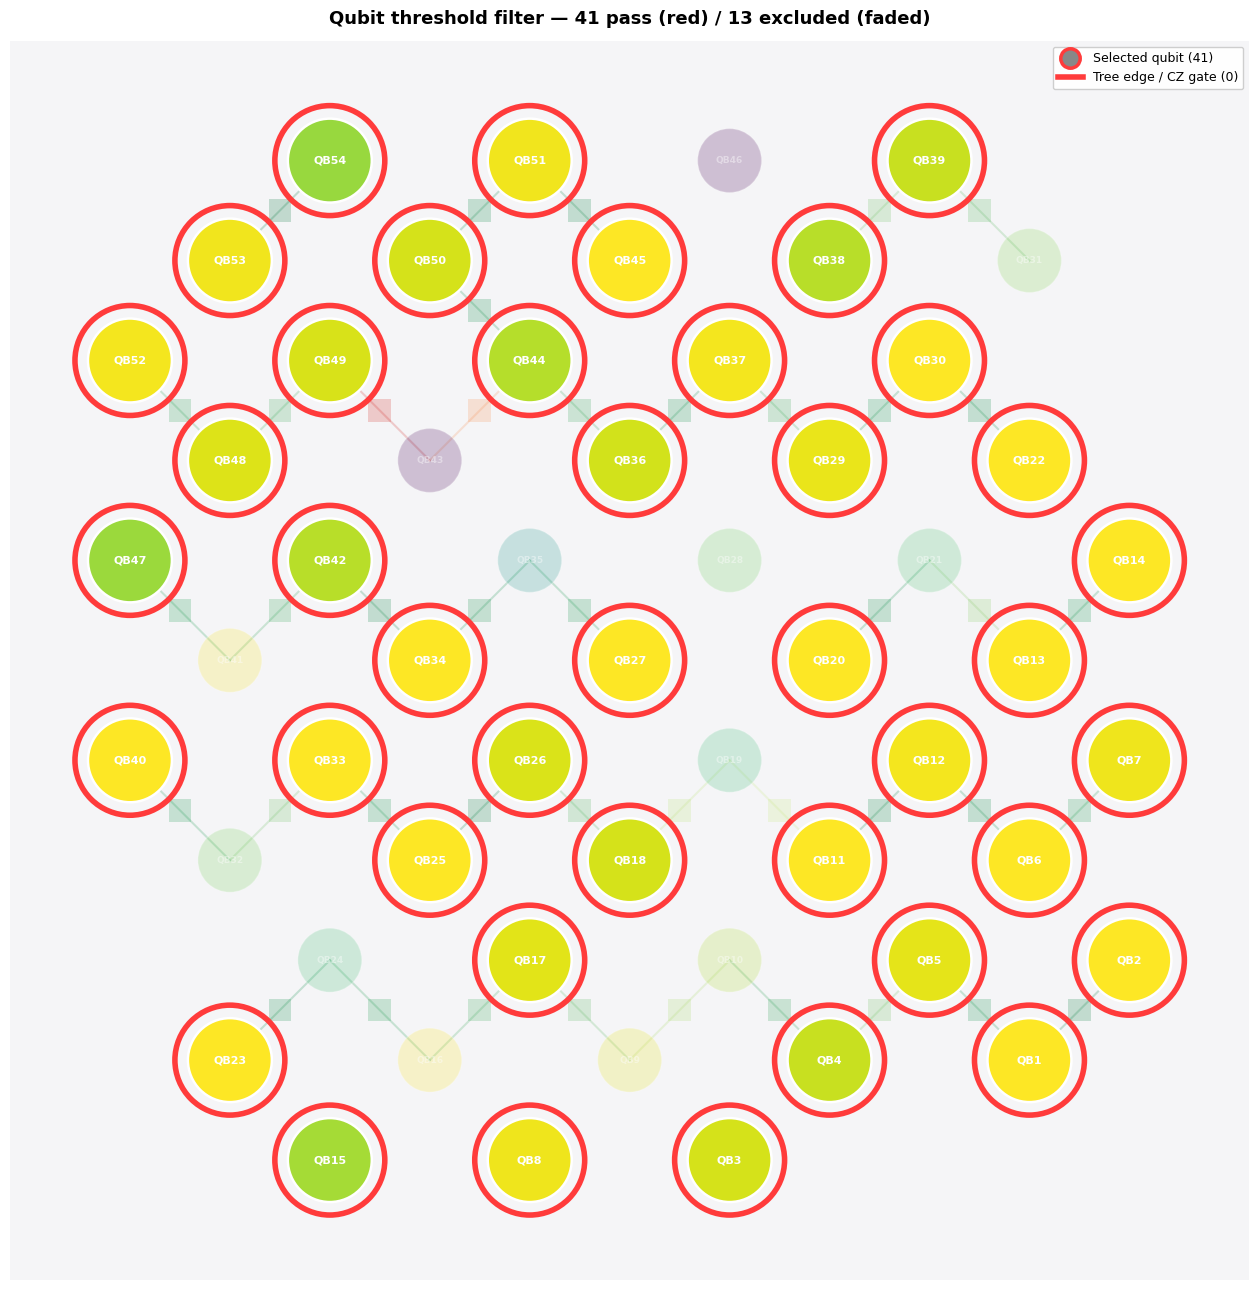

In [4]:
# Visualise which qubits passed / failed on the chip topology
fig, ax = plt.subplots(figsize=(13, 13))
plot_device_topology(
    backend, metrics=qm, cz_fidelities=cz, color_by='readout_fidelity',
    highlight_qubits=sorted(good),
    title=f'Qubit threshold filter — {len(good)} pass (red) / {len(excluded)} excluded (faded)',
    ax=ax, spotlight=True,
)
plt.tight_layout()
plt.savefig('showcase_filter.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3-5 — Build edge cost, run Prim's, predict W

For each target n, find the lowest-cost spanning tree on the surviving qubits, and predict the per-stabilizer fidelity.

In [5]:
trees = {}
for n in TARGET_NS:
    t = select_best_tree(backend, n)
    trees[n] = t
    pw = t['predicted_W']
    bound = n - 1
    margin = pw / n - (n - 1) / n
    verdict = '✓ feasible' if pw > bound else '✗ predicted to fail'
    print(f'n = {n:2d}:  cost={t["weight"]:.4f}  predicted W = {pw:.3f} / {n}  '
          f'(threshold {bound}, margin {margin:+.4f})  {verdict}')
    print(f'         qubits: {t["qubits"]}')

n =  8:  cost=0.1331  predicted W = 7.593 / 8  (threshold 7, margin +0.0741)  ✓ feasible
         qubits: [33, 41, 46, 47, 48, 51, 52, 53]


n = 12:  cost=0.2137  predicted W = 11.339 / 12  (threshold 11, margin +0.0282)  ✓ feasible
         qubits: [23, 24, 25, 32, 33, 41, 46, 47, 48, 51, 52, 53]


n = 16:  cost=0.3072  predicted W = 15.026 / 16  (threshold 15, margin +0.0016)  ✓ feasible
         qubits: [16, 17, 22, 23, 24, 25, 26, 32, 33, 41, 46, 47, 48, 51, 52, 53]


n = 20:  cost=0.3982  predicted W = 18.750 / 20  (threshold 19, margin -0.0125)  ✗ predicted to fail
         qubits: [16, 17, 22, 23, 24, 25, 26, 32, 33, 34, 35, 36, 41, 44, 46, 47, 48, 51, 52, 53]


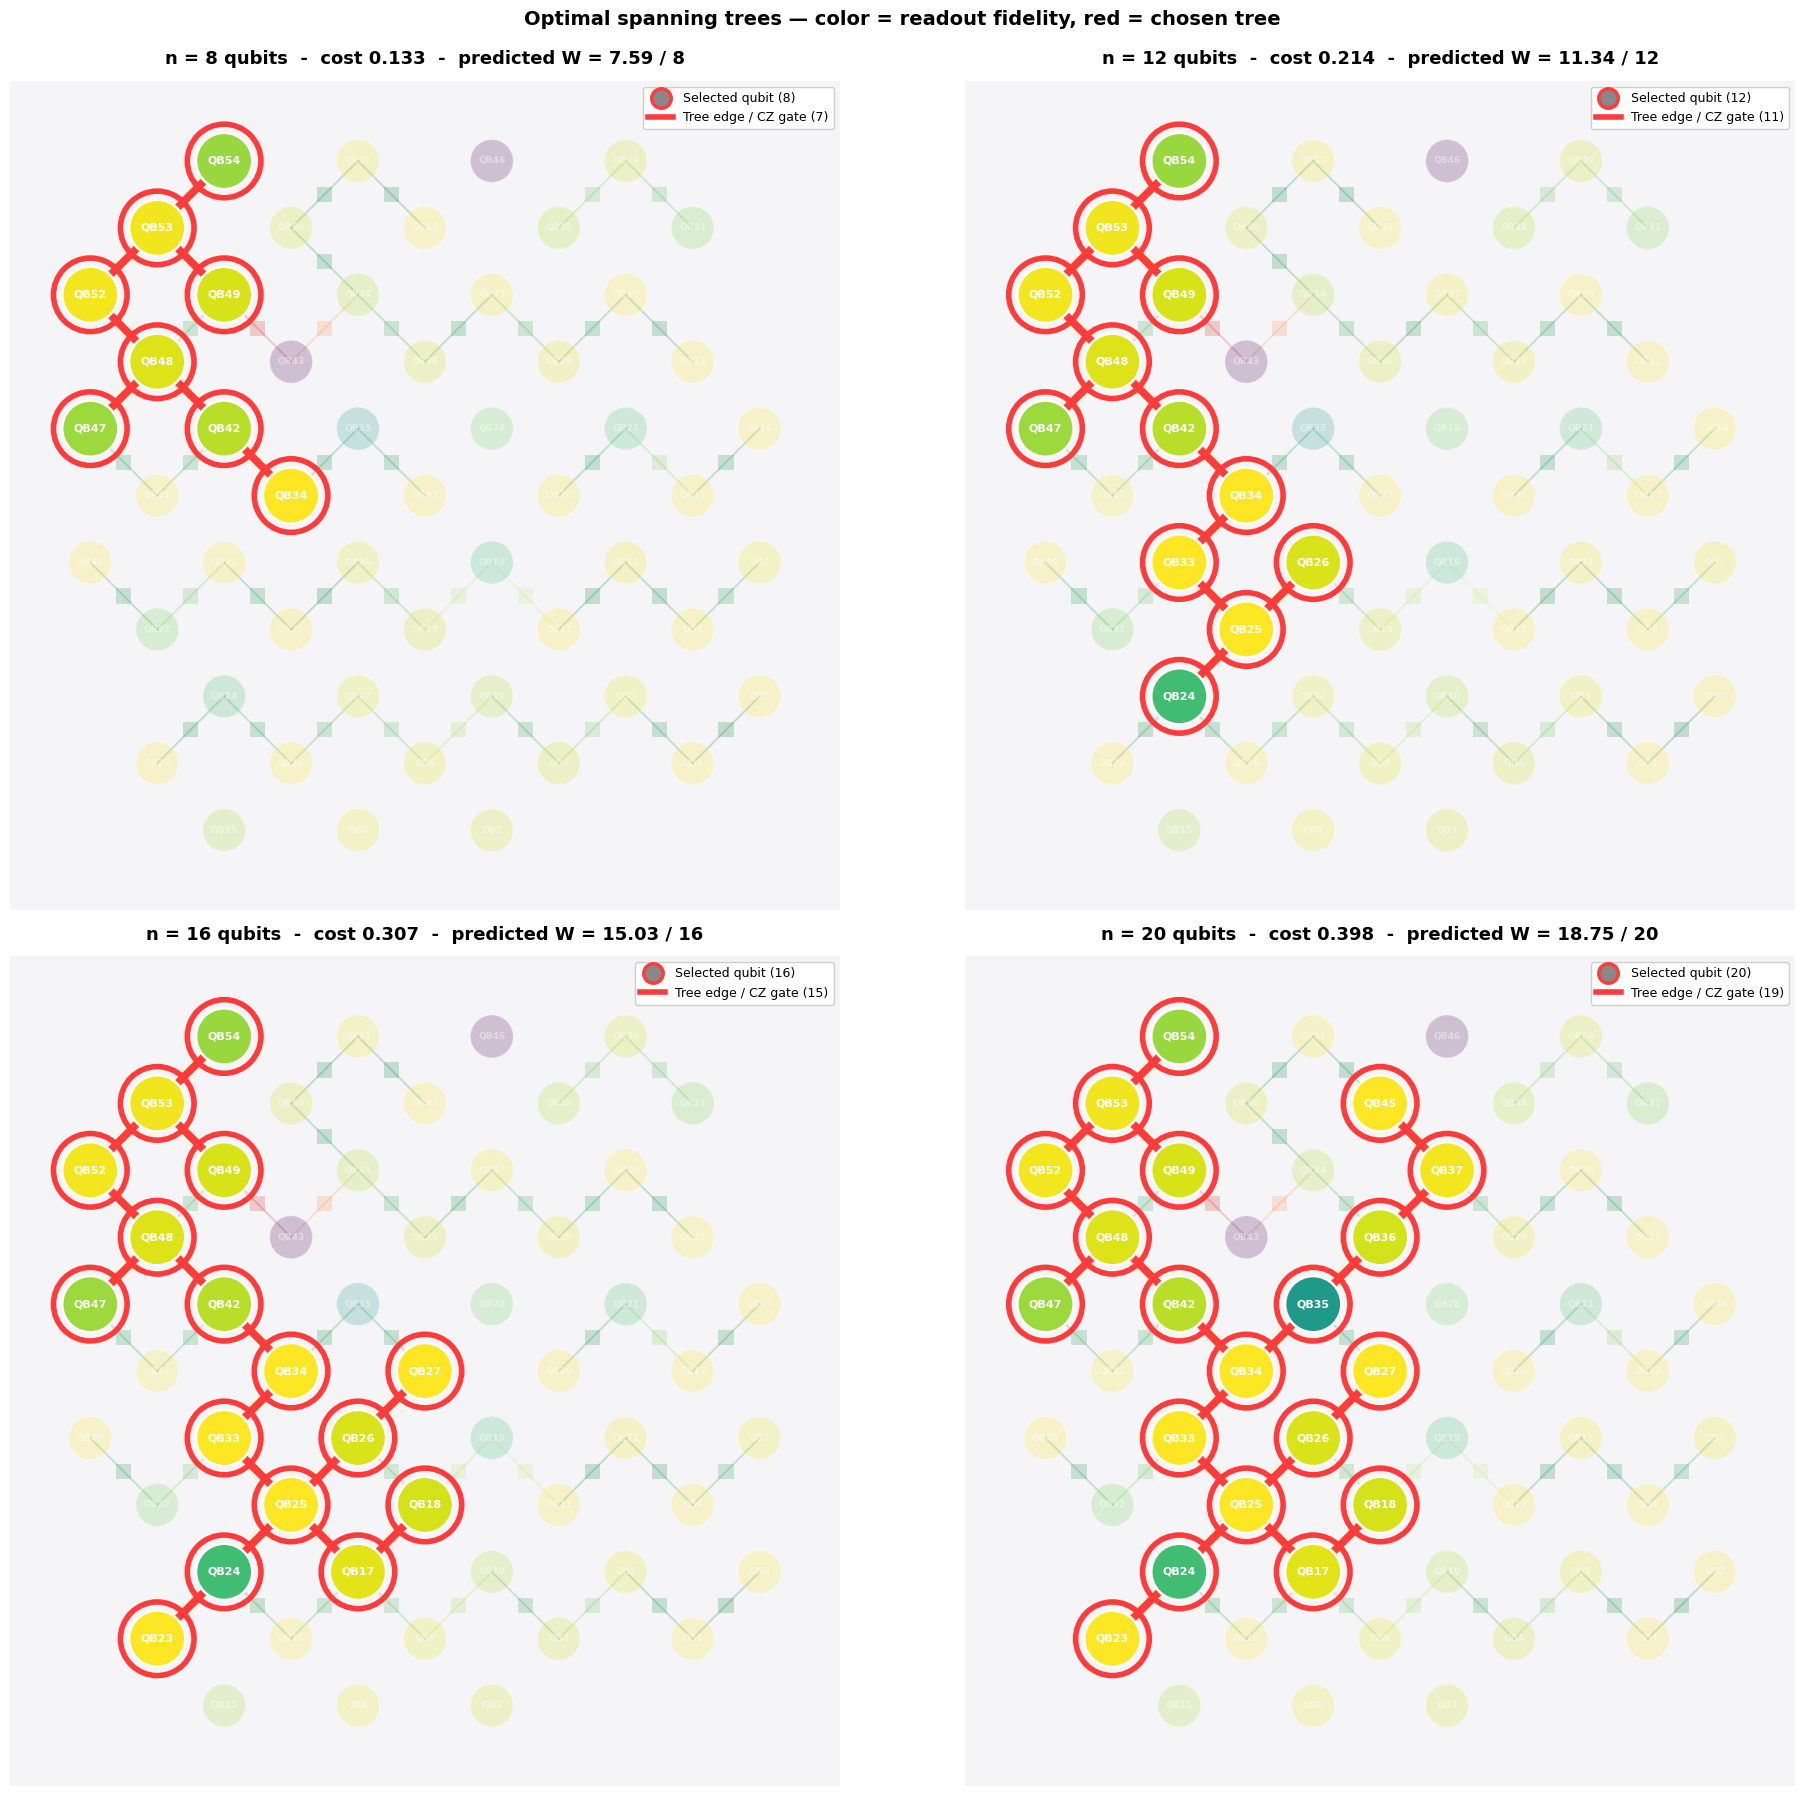

In [6]:
# Visualise each chosen tree on the chip topology (exact IQM dashboard layout)
n_trees = len(trees)
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for ax, (n, t) in zip(axes.flat, trees.items()):
    pw = t['predicted_W']
    plot_device_topology(
        backend, metrics=qm, cz_fidelities=cz, color_by='readout_fidelity',
        highlight_qubits=t['qubits'], highlight_edges=t['edges'],
        title=f'n = {n} qubits  -  cost {t["weight"]:.3f}  -  predicted W = {pw:.2f} / {n}',
        ax=ax, spotlight=True,
    )
plt.suptitle('Optimal spanning trees — color = readout fidelity, red = chosen tree',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('showcase_trees.png', dpi=110, bbox_inches='tight')
plt.show()

## Step 6-7 — Submit to IQM Emerald, compute W (raw + QREM)

One job per tree, each with 2 measurement circuits. Total: 4 jobs, ~ 4 IQM tokens.

In [7]:
correction_factors = correction_factors_from_metrics(qm) if not is_simulator(backend) else {}

results = []
for n, tree in trees.items():
    print(f'\n=== n = {n} ===', flush=True)
    qubits = tree['qubits']
    edges = tree['logical_edges']
    coloring = tree['coloring']

    state = build_graph_state(n, edges)
    circ_a, circ_b = build_gme_circuits_graph(state, coloring)
    transpiled = transpile([circ_a, circ_b], backend=backend,
                            initial_layout=qubits, optimization_level=3)
    depth_phys = transpiled[0].depth()
    n_cz_phys = transpiled[0].count_ops().get('cz', 0)

    t0 = time.time()
    job = backend.run(transpiled, shots=SHOTS)
    raw_counts = job.result().get_counts()
    elapsed = time.time() - t0

    cA, cB = (raw_counts, raw_counts) if isinstance(raw_counts, dict) else (raw_counts[0], raw_counts[1])
    res = compute_gme_witness_graph(cA, cB, n, edges, coloring)
    sigma_raw = gme_significance_graph(res['W'], n, SHOTS)
    stab_raw = res['stabilizer_values']
    raw_arr = np.array(list(stab_raw.values()))

    # Apply parity-QREM
    nbrs = neighbours_from_edges(n, edges)
    stab_mit = {}
    for q in range(n):
        involved = [q] + nbrs[q]
        factor = 1.0
        for lq in involved:
            factor *= correction_factors.get(qubits[lq], 1.0)
        stab_mit[q] = stab_raw[q] * factor
    mit_arr = np.array(list(stab_mit.values()))
    W_mit = float(mit_arr.sum())
    sigma_mit = gme_significance_graph(W_mit, n, SHOTS)

    results.append({
        'n': n, 'qubits': qubits, 'logical_edges': edges, 'coloring': coloring,
        'tree_cost': tree['weight'],
        'predicted_W': tree['predicted_W'],
        'predicted_stab': dict(tree['predicted_stab_fidelities']),
        'depth_phys': depth_phys, 'n_cz_phys': n_cz_phys,
        'W_raw': res['W'], 'W_mit': W_mit, 'bound': n - 1,
        'sigma_raw': sigma_raw, 'sigma_mit': sigma_mit,
        'is_gme_raw': res['is_gme'], 'is_gme_mit': W_mit > n - 1,
        'stab_raw': dict(stab_raw), 'stab_mit': dict(stab_mit),
        'stab_raw_mean': float(raw_arr.mean()), 'stab_raw_std': float(raw_arr.std()),
        'stab_mit_mean': float(mit_arr.mean()), 'stab_mit_std': float(mit_arr.std()),
        'job_elapsed_s': elapsed,
    })

    print(f'  predicted W: {tree["predicted_W"]:.3f}')
    print(f'  raw  W={res["W"]:.3f}  σ={sigma_raw:6.2f}  ⟨g⟩={raw_arr.mean():.3f}  GME={"✓" if res["is_gme"] else "✗"}')
    print(f'  +QREM W={W_mit:.3f}  σ={sigma_mit:6.2f}  ⟨g⟩={mit_arr.mean():.3f}  GME={"✓" if W_mit > n-1 else "✗"}')
    print(f'  job: {elapsed:.1f}s,  CZ gates {n_cz_phys}, depth {depth_phys}')


=== n = 8 ===


Progress in queue:   0%|          | 0/19 [00:00<?, ?it/s]

  predicted W: 7.593
  raw  W=7.253  σ=  3.47  ⟨g⟩=0.907  GME=✓
  +QREM W=8.063  σ= 14.56  ⟨g⟩=1.008  GME=✓
  job: 29.7s,  CZ gates 7, depth 9

=== n = 12 ===


Progress in queue:   0%|          | 0/15 [00:00<?, ?it/s]

  predicted W: 11.339
  raw  W=10.739  σ= -2.92  ⟨g⟩=0.895  GME=✗
  +QREM W=11.956  σ= 10.69  ⟨g⟩=0.996  GME=✓
  job: 25.4s,  CZ gates 11, depth 13

=== n = 16 ===


  predicted W: 15.026
  raw  W=12.465  σ=-24.54  ⟨g⟩=0.779  GME=✗
  +QREM W=13.921  σ=-10.44  ⟨g⟩=0.870  GME=✗
  job: 5.0s,  CZ gates 15, depth 15

=== n = 20 ===


  predicted W: 18.750
  raw  W=15.608  σ=-29.38  ⟨g⟩=0.780  GME=✗
  +QREM W=17.661  σ=-11.59  ⟨g⟩=0.883  GME=✗
  job: 5.0s,  CZ gates 19, depth 15


## Step 8 — Results table

In [8]:
import pandas as pd
df = pd.DataFrame([
    {
        'n': r['n'], 'bound': r['bound'],
        'cost': round(r['tree_cost'], 3),
        'pred W': round(r['predicted_W'], 2),
        'W raw': round(r['W_raw'], 2), 'σ raw': round(r['sigma_raw'], 1),
        '⟨g⟩ raw': round(r['stab_raw_mean'], 3),
        'W +QREM': round(r['W_mit'], 2), 'σ +QREM': round(r['sigma_mit'], 1),
        '⟨g⟩ +QREM': round(r['stab_mit_mean'], 3),
        'CZs': r['n_cz_phys'], 'depth': r['depth_phys'],
        'GME (raw)': '✓' if r['is_gme_raw'] else '✗',
        'GME (mit)': '✓' if r['is_gme_mit'] else '✗',
    } for r in results
])
print(df.to_string(index=False))
print()
max_raw = max((r['n'] for r in results if r['is_gme_raw']), default=0)
max_mit = max((r['n'] for r in results if r['is_gme_mit']), default=0)
print(f'Max GME certified raw   : {max_raw} qubits')
print(f'Max GME certified +QREM : {max_mit} qubits')

 n  bound  cost  pred W  W raw  σ raw  ⟨g⟩ raw  W +QREM  σ +QREM  ⟨g⟩ +QREM  CZs  depth GME (raw) GME (mit)
 8      7 0.133    7.59   7.25    3.5    0.907     8.06     14.6      1.008    7      9         ✓         ✓
12     11 0.214   11.34  10.74   -2.9    0.895    11.96     10.7      0.996   11     13         ✗         ✓
16     15 0.307   15.03  12.47  -24.5    0.779    13.92    -10.4      0.870   15     15         ✗         ✗
20     19 0.398   18.75  15.61  -29.4    0.780    17.66    -11.6      0.883   19     15         ✗         ✗

Max GME certified raw   : 8 qubits
Max GME certified +QREM : 12 qubits


## Predicted vs measured W

How well does the a-priori predictor track the actual hardware result?

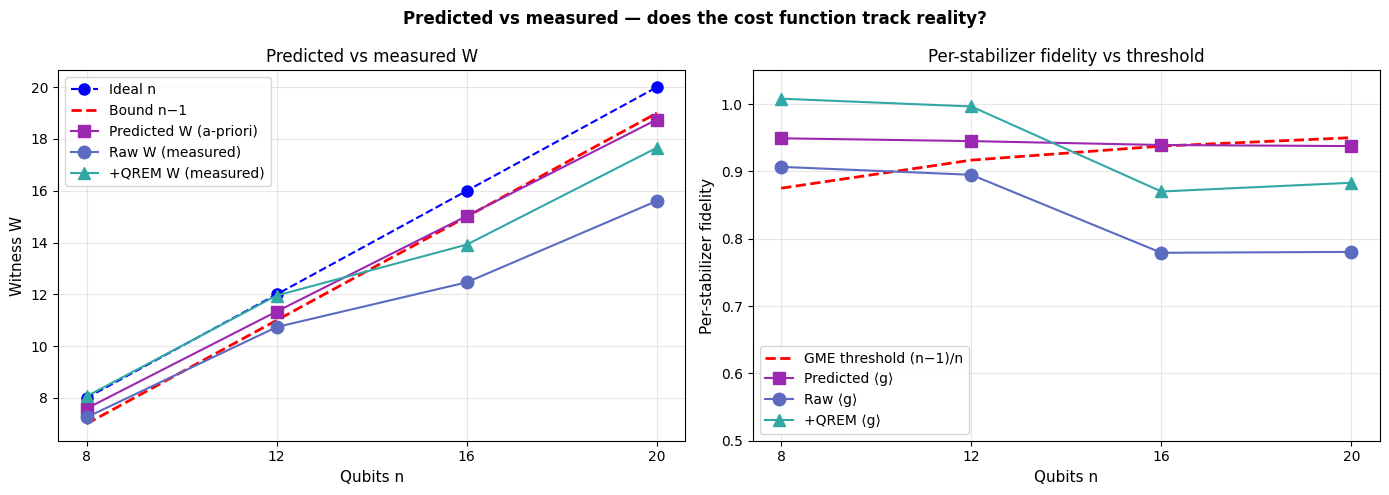

In [9]:
ns = [r['n'] for r in results]
pred = [r['predicted_W'] for r in results]
raw  = [r['W_raw']        for r in results]
mit  = [r['W_mit']        for r in results]
ideal = ns
bound = [n-1 for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ns, ideal, 'b--o', label='Ideal n', markersize=8)
ax.plot(ns, bound, 'r--', linewidth=2, label='Bound n−1')
ax.plot(ns, pred, 's-', color='#9c27b0', label='Predicted W (a-priori)', markersize=9)
ax.plot(ns, raw, 'o-', color='#5c6bc0', label='Raw W (measured)', markersize=9)
ax.plot(ns, mit, '^-', color='#32a8a4', label='+QREM W (measured)', markersize=9)
ax.set_xlabel('Qubits n', fontsize=11)
ax.set_ylabel('Witness W', fontsize=11)
ax.set_title('Predicted vs measured W')
ax.legend(loc='upper left')
ax.set_xticks(ns); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ns, [(n-1)/n for n in ns], 'r--', linewidth=2, label='GME threshold (n−1)/n')
ax.plot(ns, [p/n for p, n in zip(pred, ns)], 's-', color='#9c27b0', label='Predicted ⟨g⟩', markersize=9)
ax.plot(ns, [r['stab_raw_mean'] for r in results], 'o-', color='#5c6bc0', label='Raw ⟨g⟩', markersize=9)
ax.plot(ns, [r['stab_mit_mean'] for r in results], '^-', color='#32a8a4', label='+QREM ⟨g⟩', markersize=9)
ax.set_xlabel('Qubits n', fontsize=11)
ax.set_ylabel('Per-stabilizer fidelity', fontsize=11)
ax.set_title('Per-stabilizer fidelity vs threshold')
ax.set_xticks(ns); ax.set_ylim(0.5, 1.05); ax.grid(True, alpha=0.3)
ax.legend(loc='lower left')

plt.suptitle('Predicted vs measured — does the cost function track reality?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('showcase_pred_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()

## Per-qubit stabilizer values — raw vs mitigated

Map of ⟨g_i⟩ on the actual chip layout. Top row = raw measured, bottom row = after parity-QREM.

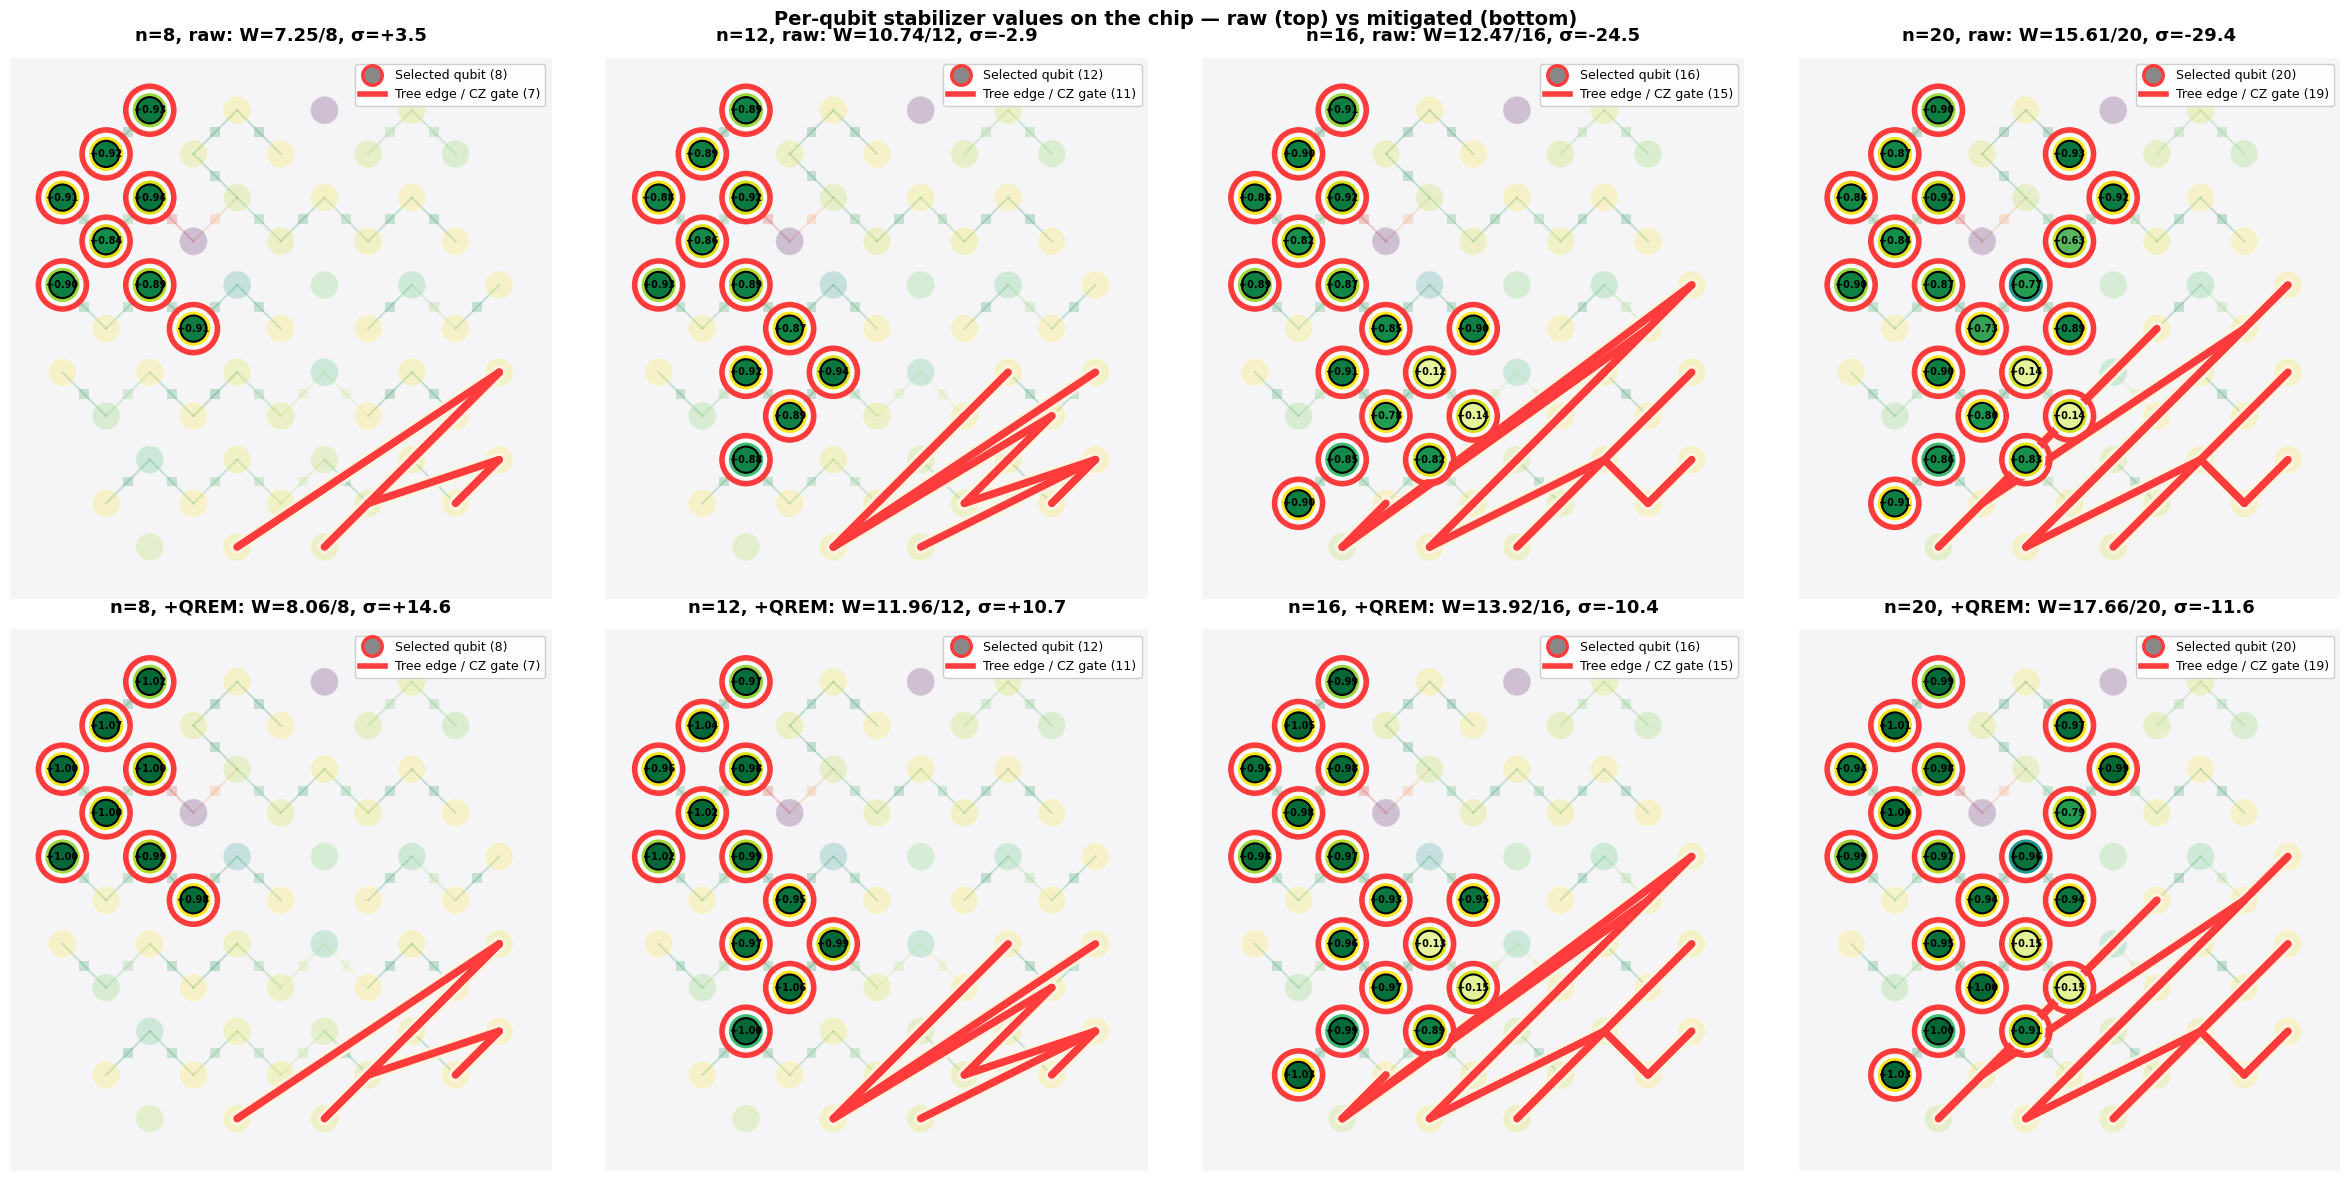

In [10]:
from matplotlib.cm import RdYlGn
import matplotlib.patches as mpatches

pos = _device_layout(backend)
fig, axes = plt.subplots(2, len(results), figsize=(6*len(results), 12), squeeze=False)

for col, r in enumerate(results):
    n = r['n']
    qubits = r['qubits']
    for row_idx, key in enumerate(['stab_raw', 'stab_mit']):
        ax = axes[row_idx, col]
        # Plot full chip faded
        plot_device_topology(
            backend, metrics=qm, cz_fidelities=cz, color_by='readout_fidelity',
            highlight_qubits=qubits, highlight_edges=r['logical_edges'],
            ax=ax, spotlight=True, show_labels=False, pos=pos,
            title=f"n={n}, {'raw' if key=='stab_raw' else '+QREM'}: "
                   f"W={r['W_raw' if key=='stab_raw' else 'W_mit']:.2f}/{n}, "
                   f"σ={r['sigma_raw' if key=='stab_raw' else 'sigma_mit']:+.1f}",
        )
        # Overlay per-qubit stabilizer values as colored circles
        for lq, val in r[key].items():
            pq = qubits[lq]
            x, y = pos[pq]
            color = RdYlGn((val + 1) / 2)
            ax.add_patch(mpatches.Circle((x, y), radius=0.30, facecolor=color,
                                          edgecolor='black', linewidth=1.5, zorder=15))
            ax.text(x, y, f'{val:+.2f}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='black', zorder=16)

plt.suptitle('Per-qubit stabilizer values on the chip — raw (top) vs mitigated (bottom)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('showcase_heatmaps.png', dpi=110, bbox_inches='tight')
plt.show()

## Summary

In [11]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
max_raw = max((r['n'] for r in results if r['is_gme_raw']), default=0)
max_mit = max((r['n'] for r in results if r['is_gme_mit']), default=0)
print(f'  Max GME certified, raw      : {max_raw} qubits')
print(f'  Max GME certified, +QREM    : {max_mit} qubits')
print(f'  Total IQM job time          : {sum(r["job_elapsed_s"] for r in results):.1f} s')
print(f'  Total CZ gates executed     : {sum(r["n_cz_phys"] * 2 for r in results)}')
print()
print('Predictor accuracy (predW vs +QREM W):')
for r in results:
    err = r['W_mit'] - r['predicted_W']
    print(f'  n={r["n"]:2d}: predicted {r["predicted_W"]:.2f}  →  measured (mit) {r["W_mit"]:.2f}  '
          f'(error {err:+.2f}, {abs(err)/r["n"]*100:.1f}% of n)')

import json
with open('showcase_results.json', 'w') as f:
    json.dump([
        {**r, 'stab_raw': {str(k): v for k, v in r['stab_raw'].items()},
             'stab_mit': {str(k): v for k, v in r['stab_mit'].items()},
             'predicted_stab': {str(k): v for k, v in r['predicted_stab'].items()}}
        for r in results
    ], f, indent=2)
print('\nFull data saved to showcase_results.json')

FINAL SUMMARY
  Max GME certified, raw      : 8 qubits
  Max GME certified, +QREM    : 12 qubits
  Total IQM job time          : 65.1 s
  Total CZ gates executed     : 104

Predictor accuracy (predW vs +QREM W):
  n= 8: predicted 7.59  →  measured (mit) 8.06  (error +0.47, 5.9% of n)
  n=12: predicted 11.34  →  measured (mit) 11.96  (error +0.62, 5.1% of n)
  n=16: predicted 15.03  →  measured (mit) 13.92  (error -1.10, 6.9% of n)
  n=20: predicted 18.75  →  measured (mit) 17.66  (error -1.09, 5.4% of n)

Full data saved to showcase_results.json
